# MS-CXR-T Temporal Progression Evaluation (K=1 vs K=4)

Evaluates the BioViL-T multi-prior checkpoints on the MS-CXR-T temporal
image-classification task using:

* **Linear probe** over the frozen fused image embedding (`img_global`, 128-d), with `GroupKFold` by `subject_id` (no patient leakage).
* **Zero-shot text prompts** (BioViL-T style): cosine similarity of `img_global` to per-class text prompts.

Each MS-CXR-T row provides a (current, prior, pathology, progression) label. We feed the model `current + K priors` where `prior_0` = the labeled prior and `prior_1..` = older MIMIC frontal priors (newest-first), so the label always refers to the current↔prior_0 transition, and K just adds older context.

### What's on Google Drive

The notebook reads from `/content/drive/MyDrive/output_share/` (shortcut). Expected layout:

```
output_share/
  mscxrt.zip                       # MIMIC-layout JPGs (pXX/pSUBJECT/sSTUDY/*.jpg)
  mscxrt_eval_imagelevel.csv       # built by biovilt/build_mscxrt_eval.py
  subset_checkpoints_4_3.zip       # K=4 trained checkpoint (contains best.pt)
  gcp-k1/
    subset_checkpoints_1.zip       # K=1 trained checkpoint (contains best.pt)
```

Heavy files (mscxrt.zip, both checkpoint zips) are **extracted to the Colab VM** under `/content/` so inference doesn't hit Drive on every image read. The eval CSV is read directly from Drive (tiny). The notebook clones the repo and reuses `BioViLTDataset` and `TempCXR` unchanged.

## 1. Install deps + clone repo

In [1]:
%pip install -q transformers hi-ml-multimodal scikit-learn matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 48.5 MB/s eta 0:00:00


In [2]:
import os, sys, subprocess

REPO_URL  = 'https://github.com/nprakash1/cxr-temporal-multiprior.git'
REPO_PATH = '/content/cxr-temporal'
REPO_BRANCH = 'gcp-release'

if not os.path.isdir(REPO_PATH):
    subprocess.check_call(['git','clone','--depth','1','-b', REPO_BRANCH, REPO_URL, REPO_PATH])
sys.path.insert(0, REPO_PATH)
sys.path.insert(0, os.path.join(REPO_PATH, 'biovilt'))
print('repo at:', REPO_PATH)

repo at: /content/cxr-temporal


## 2. Mount Drive + configure paths

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, glob, time
from pathlib import Path

# ---- 1. Drive paths (the output_share shortcut you added to MyDrive) ----
OUTPUT_SHARE = '/content/drive/MyDrive/output_share'
ZIP_MSCXRT   = os.path.join(OUTPUT_SHARE, 'mscxrt.zip')
ZIP_K4       = os.path.join(OUTPUT_SHARE, 'subset_checkpoints_4_3.zip')   # K=4 weights
ZIP_K1       = os.path.join(OUTPUT_SHARE, 'gcp-k1', 'subset_checkpoints_1.zip')  # K=1 weights
EVAL_CSV     = os.path.join(OUTPUT_SHARE, 'mscxrt_eval_imagelevel.csv')   # read directly from Drive

assert os.path.exists(OUTPUT_SHARE), f'output_share not found — open {OUTPUT_SHARE} in the Files pane and verify the shortcut'
for label, p in [('mscxrt.zip', ZIP_MSCXRT), ('K=1 zip', ZIP_K1),
                  ('K=4 zip',   ZIP_K4),     ('eval csv', EVAL_CSV)]:
    print(f'{label:11s}: {p}   exists={os.path.exists(p)}')

# ---- 2. Extract to fast local /content/ scratch (skip if already done) ----
LOCAL = Path('/content/eval_work'); LOCAL.mkdir(exist_ok=True)
MSCXRT_DIR = LOCAL / 'mscxrt'
K1_DIR     = LOCAL / 'ckpt_k1'
K4_DIR     = LOCAL / 'ckpt_k4'

def _unzip(zip_path, dest_dir, sentinel_glob):
    dest_dir = Path(dest_dir)
    if dest_dir.exists() and list(dest_dir.rglob(sentinel_glob)):
        print(f'  [skip] {dest_dir} already populated')
        return
    dest_dir.mkdir(parents=True, exist_ok=True)
    t0 = time.time()
    print(f'  unzip {zip_path}  ->  {dest_dir}   ...', end='', flush=True)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(dest_dir)
    print(f' done in {time.time()-t0:.1f}s')

print('\n[unzip] images ...')
_unzip(ZIP_MSCXRT, MSCXRT_DIR, sentinel_glob='*.jpg')
print('[unzip] K=1 checkpoint ...')
_unzip(ZIP_K1,     K1_DIR,     sentinel_glob='*.pt')
print('[unzip] K=4 checkpoint ...')
_unzip(ZIP_K4,     K4_DIR,     sentinel_glob='*.pt')

# ---- 3. Auto-detect IMG_ROOT (folder containing the pXX/... MIMIC layout) ----
def _find_mimic_root(base):
    base = Path(base)
    # The pXX top-level folders are p10..p19 in MIMIC-CXR; search up to depth 4.
    for cand in [base] + [p.parent for p in base.rglob('p1[0-9]') if p.is_dir()][:1]:
        if any((cand / f'p1{i}').is_dir() for i in range(10)):
            return str(cand)
    raise FileNotFoundError(f'Could not find MIMIC pXX layout under {base}')
IMG_ROOT = _find_mimic_root(MSCXRT_DIR)

# ---- 4. Auto-detect best.pt inside each extracted checkpoint dir ----
def _find_best_pt(base):
    base = Path(base)
    cands = sorted(base.rglob('best.pt'))
    if cands: return str(cands[0])
    cands = sorted(base.rglob('*.pt'))
    if not cands:
        raise FileNotFoundError(f'No .pt under {base}')
    # Prefer files whose name contains 'best', else largest.
    cands.sort(key=lambda p: ('best' not in p.name.lower(), -p.stat().st_size))
    return str(cands[0])
CKPT_K1 = _find_best_pt(K1_DIR)
CKPT_K4 = _find_best_pt(K4_DIR)

print('\nResolved paths:')
for label, p in [('image root', IMG_ROOT), ('eval csv', EVAL_CSV),
                  ('K=1 ckpt',  CKPT_K1),  ('K=4 ckpt', CKPT_K4)]:
    print(f'  {label:11s}: {p}   exists={os.path.exists(p)}')

Mounted at /content/drive
mscxrt.zip : /content/drive/MyDrive/output_share/mscxrt.zip   exists=True
K=1 zip    : /content/drive/MyDrive/output_share/gcp-k1/subset_checkpoints_1.zip   exists=True
K=4 zip    : /content/drive/MyDrive/output_share/subset_checkpoints_4_3.zip   exists=True
eval csv   : /content/drive/MyDrive/output_share/mscxrt_eval_imagelevel.csv   exists=True

[unzip] images ...
  unzip /content/drive/MyDrive/output_share/mscxrt.zip  ->  /content/eval_work/mscxrt   ... done in 150.8s
[unzip] K=1 checkpoint ...
  unzip /content/drive/MyDrive/output_share/gcp-k1/subset_checkpoints_1.zip  ->  /content/eval_work/ckpt_k1   ... done in 153.8s
[unzip] K=4 checkpoint ...
  unzip /content/drive/MyDrive/output_share/subset_checkpoints_4_3.zip  ->  /content/eval_work/ckpt_k4   ... done in 135.1s

Resolved paths:
  image root : /content/eval_work/mscxrt/mscxrt   exists=True
  eval csv   : /content/drive/MyDrive/output_share/mscxrt_eval_imagelevel.csv   exists=True
  K=1 ckpt   : /cont

## 3. Imports + helpers

In [4]:
import json, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader

from biovilt.dataset import BioViLTDataset, biovilt_collate_fn
from biovilt.tempcxr.modules.tempcxr_model import TempCXR

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE, '| gpu:', torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'n/a')

device: cuda | gpu: NVIDIA A100-SXM4-80GB


In [5]:
def build_loader(k_max, batch_size, num_workers=2):
    ds = BioViLTDataset(
        csv_path=EVAL_CSV, image_root=IMG_ROOT,
        split='test', train=False, k_max=k_max,
    )
    dl = DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
        collate_fn=biovilt_collate_fn,
    )
    return ds, dl

def load_model(ckpt_path, k_max, mode='biovilt'):
    """Build TempCXR(mode, K_max) and load the trained weights.
    Handles raw state_dicts, dicts with 'model_state_dict'/'state_dict',
    and DDP 'module.' prefixes. Uses strict=False since the text encoder
    HuggingFace blobs are reloaded from upstream."""
    model = TempCXR(mode=mode, K_max=k_max).to(DEVICE)
    sd = torch.load(ckpt_path, map_location='cpu')
    if isinstance(sd, dict):
        for key in ('model', 'model_state_dict', 'state_dict'):
            if key in sd and isinstance(sd[key], dict):
                sd = sd[key]; break
    sd = {(k[7:] if k.startswith('module.') else k): v for k, v in sd.items()}
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f'   loaded {ckpt_path}\n   missing={len(missing)}  unexpected={len(unexpected)}')
    model.eval()
    return model

@torch.no_grad()
def extract_embeddings(model, dl):
    feats = []
    for i, batch in enumerate(dl):
        curr   = batch['current_image'].to(DEVICE, non_blocking=True)
        priors = batch['prior_images']
        mask   = batch['prior_mask']
        if priors is not None: priors = priors.to(DEVICE, non_blocking=True)
        if mask   is not None: mask   = mask.to(DEVICE, non_blocking=True)
        img_global, _ = model.image_encoder(curr, priors, mask)
        feats.append(img_global.cpu().numpy())
        if (i+1) % 20 == 0:
            print(f'  batch {i+1}/{len(dl)}')
    return np.concatenate(feats, axis=0)

@torch.no_grad()
def embed_prompts(model, prompts):
    """Prompt-ensemble per class.

    Args:
        prompts: dict pathology -> list[list[str]] of length 3 (one inner
                 list of paraphrases per MS-CXR-T class, in the order
                 [improving, stable, worsening]).
    Returns:
        dict pathology -> np.ndarray (3, D), unit-normalized.
        Each row is the mean of the per-paraphrase txt_global embeddings
        for that class, then L2-normalized — standard BioViL-T-style
        prompt averaging for zero-shot classification.
    """
    out = {}
    for p, cls_prompts in prompts.items():
        rows = []
        for class_prompts in cls_prompts:
            txt_global, _, _ = model.text_encoder.forward_contrastive(class_prompts)
            mean_emb = txt_global.mean(dim=0, keepdim=True)
            mean_emb = torch.nn.functional.normalize(mean_emb, dim=-1)
            rows.append(mean_emb)
        out[p] = torch.cat(rows, dim=0).cpu().numpy()   # (3, D)
    return out

## 4. Read labels (aligned with dataloader order)

In [6]:
df = pd.read_csv(EVAL_CSV)
print('rows:', len(df))
print(df[['progression_label','pathology','num_priors','num_older_priors']].head())

CLASSES = ['improving', 'stable', 'worsening']
y           = np.array([CLASSES.index(s) for s in df['progression_label']])
pathologies = df['pathology'].values
subjects    = df['subject_id'].values
pathologies_unique = sorted(np.unique(pathologies).tolist())
print('\nlabel counts:'); print(pd.Series(df['progression_label']).value_counts())
print('\npathology counts:'); print(pd.Series(pathologies).value_counts())
print('\nunique subjects:', len(np.unique(subjects)))

rows: 1326
  progression_label         pathology  num_priors  num_older_priors
0            stable     consolidation           4                 3
1            stable         pneumonia           4                 3
2         improving  pleural effusion           4                 3
3         worsening         pneumonia           1                 0
4         worsening         pneumonia           4                 3

label counts:
progression_label
worsening    555
stable       530
improving    241
Name: count, dtype: int64

pathology counts:
pleural effusion    411
edema               266
pneumonia           237
pneumothorax        211
consolidation       201
Name: count, dtype: int64

unique subjects: 800


## 5. Extract image embeddings + per-pathology text-prompt embeddings

For each checkpoint we run one inference pass over the eval set to get the fused 128-d `img_global` for every row, and we embed an ensemble of prompts for each MS-CXR-T class (`improving / stable / worsening` — the literal label words used in MS-CXR-T's `comparison` column). The text encoder is the **same checkpoint's** text encoder, so image and text vectors live in the same space.

In [7]:
# Per-pathology prompt ensemble. CLASSES order is [improving, stable, worsening]
# (the literal MS-CXR-T 'comparison' label values). For each class we use a small
# set of clinical paraphrases (including the literal label word) which are embedded
# and mean-pooled before similarity scoring -- standard BioViL-T-style zero-shot.
_CLASS_PARAPHRASES = {
    'improving': [
        'the {p} is improving',
        'improvement in {p}',
        'decreased {p}',
        '{p} has improved',
    ],
    'stable': [
        'the {p} is stable',
        'no change in {p}',
        '{p} is unchanged',
        'stable {p}',
    ],
    'worsening': [
        'the {p} is worsening',
        'worsening {p}',
        'increased {p}',
        '{p} has worsened',
    ],
}
prompts_for_pathology = {
    p: [[tpl.format(p=p) for tpl in _CLASS_PARAPHRASES[c]] for c in CLASSES]
    for p in pathologies_unique
}
print('prompts (showing one pathology):')
for c, plist in zip(CLASSES, prompts_for_pathology[pathologies_unique[0]]):
    print(f'  {c:10s}:', plist)

prompts (showing one pathology):
  improving : ['the consolidation is improving', 'improvement in consolidation', 'decreased consolidation', 'consolidation has improved']
  stable    : ['the consolidation is stable', 'no change in consolidation', 'consolidation is unchanged', 'stable consolidation']
  worsening : ['the consolidation is worsening', 'worsening consolidation', 'increased consolidation', 'consolidation has worsened']


In [8]:
def run_checkpoint(ckpt_path, k_max, batch_size):
    print(f'=== {ckpt_path}  (k_max={k_max}, bs={batch_size}) ===')
    ds, dl = build_loader(k_max=k_max, batch_size=batch_size)
    model = load_model(ckpt_path, k_max=k_max)
    img_emb = extract_embeddings(model, dl)
    txt_emb = embed_prompts(model, prompts_for_pathology)
    print('  image embeddings:', img_emb.shape)
    print('  prompt embeddings per pathology:',
          {p: v.shape for p, v in txt_emb.items()})
    del model
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    return img_emb, txt_emb

emb_k1, prompt_emb_k1 = run_checkpoint(CKPT_K1, k_max=1, batch_size=8)
emb_k4, prompt_emb_k4 = run_checkpoint(CKPT_K4, k_max=4, batch_size=4)

=== /content/eval_work/ckpt_k1/subset_checkpoints/best.pt  (k_max=1, bs=8) ===


100%|██████████| 110M/110M [00:01<00:00, 71.3MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/803 [00:00<?, ?B/s]

configuration_cxrbert.py:   0%|          | 0.00/888 [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/microsoft/BiomedVLP-BioViL-T:
- configuration_cxrbert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

[transformers] CXRBertModel LOAD REPORT from: microsoft/BiomedVLP-BioViL-T
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


   loaded /content/eval_work/ckpt_k1/subset_checkpoints/best.pt
   missing=0  unexpected=0
  batch 20/166
  batch 40/166
  batch 60/166
  batch 80/166
  batch 100/166
  batch 120/166
  batch 140/166
  batch 160/166
  image embeddings: (1326, 128)
  prompt embeddings per pathology: {'consolidation': (3, 128), 'edema': (3, 128), 'pleural effusion': (3, 128), 'pneumonia': (3, 128), 'pneumothorax': (3, 128)}
=== /content/eval_work/ckpt_k4/subset_checkpoints/best.pt  (k_max=4, bs=4) ===


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] CXRBertModel LOAD REPORT from: microsoft/BiomedVLP-BioViL-T
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   loaded /content/eval_work/ckpt_k4/subset_checkpoints/best.pt
   missing=0  unexpected=0
  batch 20/332
  batch 40/332
  batch 60/332
  batch 80/332
  batch 100/332
  batch 120/332
  batch 140/332
  batch 160/332
  batch 180/332
  batch 200/332
  batch 220/332
  batch 240/332
  batch 260/332
  batch 280/332
  batch 300/332
  batch 320/332
  image embeddings: (1326, 128)
  prompt embeddings per pathology: {'consolidation': (3, 128), 'edema': (3, 128), 'pleural effusion': (3, 128), 'pneumonia': (3, 128), 'pneumothorax': (3, 128)}


## 6. Linear probe (GroupKFold by subject)

Freeze the encoder, fit a logistic regression on the 128-d image embedding, evaluate with 5-fold cross-validation **grouped by `subject_id`** so the same patient never appears in both train and test of a fold. We report accuracy and macro-F1 overall and per pathology.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score

def probe_eval(X, y, groups, pathologies_arr, n_splits=5, name=''):
    gkf = GroupKFold(n_splits=n_splits)
    accs, f1s = [], []
    by_path = {}
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups)):
        sc = StandardScaler().fit(X[tr])
        clf = LogisticRegression(max_iter=2000, multi_class='multinomial', C=1.0)
        clf.fit(sc.transform(X[tr]), y[tr])
        pred = clf.predict(sc.transform(X[te]))
        accs.append(accuracy_score(y[te], pred))
        f1s.append(f1_score(y[te], pred, average='macro'))
        for p in np.unique(pathologies_arr):
            m = pathologies_arr[te] == p
            if m.sum() == 0: continue
            by_path.setdefault(p, []).append(
                f1_score(y[te][m], pred[m], average='macro', zero_division=0)
            )
    print(f'[{name}]  acc = {np.mean(accs):.3f} ± {np.std(accs):.3f}   '
          f'macro-F1 = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}')
    for p in sorted(by_path):
        v = by_path[p]
        print(f'   {p:18s}: macro-F1 {np.mean(v):.3f} ± {np.std(v):.3f}  (n_folds={len(v)})')
    return {
        'condition': name,
        'acc_mean': float(np.mean(accs)), 'acc_std': float(np.std(accs)),
        'f1_mean':  float(np.mean(f1s)),  'f1_std':  float(np.std(f1s)),
        'by_path': {p: (float(np.mean(v)), float(np.std(v))) for p, v in by_path.items()},
    }

probe_k1 = probe_eval(emb_k1, y, subjects, pathologies, name='probe / K=1 model, K=1 input')
probe_k4 = probe_eval(emb_k4, y, subjects, pathologies, name='probe / K=4 model, K=4 input')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

[probe / K=1 model, K=1 input]  acc = 0.536 ± 0.017   macro-F1 = 0.506 ± 0.023
   consolidation     : macro-F1 0.373 ± 0.063  (n_folds=5)
   edema             : macro-F1 0.549 ± 0.039  (n_folds=5)
   pleural effusion  : macro-F1 0.519 ± 0.077  (n_folds=5)
   pneumonia         : macro-F1 0.517 ± 0.052  (n_folds=5)
   pneumothorax      : macro-F1 0.355 ± 0.067  (n_folds=5)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

[probe / K=4 model, K=4 input]  acc = 0.535 ± 0.024   macro-F1 = 0.497 ± 0.029
   consolidation     : macro-F1 0.445 ± 0.045  (n_folds=5)
   edema             : macro-F1 0.483 ± 0.052  (n_folds=5)
   pleural effusion  : macro-F1 0.500 ± 0.055  (n_folds=5)
   pneumonia         : macro-F1 0.532 ± 0.105  (n_folds=5)
   pneumothorax      : macro-F1 0.324 ± 0.065  (n_folds=5)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 7. Zero-shot text prompts

For each example with pathology `p`, score the three prompts for `p` by cosine similarity to its `img_global` and take the argmax. No training.

In [10]:
def zeroshot_eval(img_emb, prompt_emb, pathologies_arr, y, name=''):
    img = img_emb / (np.linalg.norm(img_emb, axis=1, keepdims=True) + 1e-9)
    pred = np.empty(len(y), dtype=int)
    for i, p in enumerate(pathologies_arr):
        sims = img[i] @ prompt_emb[p].T   # (3,)
        pred[i] = int(np.argmax(sims))
    acc = accuracy_score(y, pred)
    f1  = f1_score(y, pred, average='macro')
    print(f'[{name}]  acc = {acc:.3f}   macro-F1 = {f1:.3f}')
    by_path = {}
    for p in np.unique(pathologies_arr):
        m = pathologies_arr == p
        by_path[p] = f1_score(y[m], pred[m], average='macro', zero_division=0)
        print(f'   {p:18s}: macro-F1 {by_path[p]:.3f}  (n={int(m.sum())})')
    return {'condition': name, 'acc': float(acc), 'f1': float(f1),
            'by_path': by_path}

zs_k1 = zeroshot_eval(emb_k1, prompt_emb_k1, pathologies, y, name='zero-shot / K=1 model')
zs_k4 = zeroshot_eval(emb_k4, prompt_emb_k4, pathologies, y, name='zero-shot / K=4 model')

[zero-shot / K=1 model]  acc = 0.459   macro-F1 = 0.441
   consolidation     : macro-F1 0.361  (n=201)
   edema             : macro-F1 0.537  (n=266)
   pleural effusion  : macro-F1 0.434  (n=411)
   pneumonia         : macro-F1 0.383  (n=237)
   pneumothorax      : macro-F1 0.346  (n=211)
[zero-shot / K=4 model]  acc = 0.375   macro-F1 = 0.373
   consolidation     : macro-F1 0.398  (n=201)
   edema             : macro-F1 0.392  (n=266)
   pleural effusion  : macro-F1 0.349  (n=411)
   pneumonia         : macro-F1 0.384  (n=237)
   pneumothorax      : macro-F1 0.281  (n=211)


## 8. Summary

In [11]:
summary = pd.DataFrame([
    {'condition': probe_k1['condition'], 'acc':  f"{probe_k1['acc_mean']:.3f} ± {probe_k1['acc_std']:.3f}",
     'macro_F1': f"{probe_k1['f1_mean']:.3f} ± {probe_k1['f1_std']:.3f}"},
    {'condition': probe_k4['condition'], 'acc':  f"{probe_k4['acc_mean']:.3f} ± {probe_k4['acc_std']:.3f}",
     'macro_F1': f"{probe_k4['f1_mean']:.3f} ± {probe_k4['f1_std']:.3f}"},
    {'condition': zs_k1['condition'], 'acc': f"{zs_k1['acc']:.3f}", 'macro_F1': f"{zs_k1['f1']:.3f}"},
    {'condition': zs_k4['condition'], 'acc': f"{zs_k4['acc']:.3f}", 'macro_F1': f"{zs_k4['f1']:.3f}"},
])
print(summary.to_string(index=False))

# Per-pathology probe macro-F1 K=1 vs K=4
rows = []
for p in pathologies_unique:
    rows.append({
        'pathology': p,
        'probe_K=1': f"{probe_k1['by_path'].get(p,(0,0))[0]:.3f} ± {probe_k1['by_path'].get(p,(0,0))[1]:.3f}",
        'probe_K=4': f"{probe_k4['by_path'].get(p,(0,0))[0]:.3f} ± {probe_k4['by_path'].get(p,(0,0))[1]:.3f}",
        'zs_K=1':    f"{zs_k1['by_path'].get(p, 0):.3f}",
        'zs_K=4':    f"{zs_k4['by_path'].get(p, 0):.3f}",
    })
print('\nPer-pathology macro-F1:')
print(pd.DataFrame(rows).to_string(index=False))

                   condition           acc      macro_F1
probe / K=1 model, K=1 input 0.536 ± 0.017 0.506 ± 0.023
probe / K=4 model, K=4 input 0.535 ± 0.024 0.497 ± 0.029
       zero-shot / K=1 model         0.459         0.441
       zero-shot / K=4 model         0.375         0.373

Per-pathology macro-F1:
       pathology     probe_K=1     probe_K=4 zs_K=1 zs_K=4
   consolidation 0.373 ± 0.063 0.445 ± 0.045  0.361  0.398
           edema 0.549 ± 0.039 0.483 ± 0.052  0.537  0.392
pleural effusion 0.519 ± 0.077 0.500 ± 0.055  0.434  0.349
       pneumonia 0.517 ± 0.052 0.532 ± 0.105  0.383  0.384
    pneumothorax 0.355 ± 0.067 0.324 ± 0.065  0.346  0.281


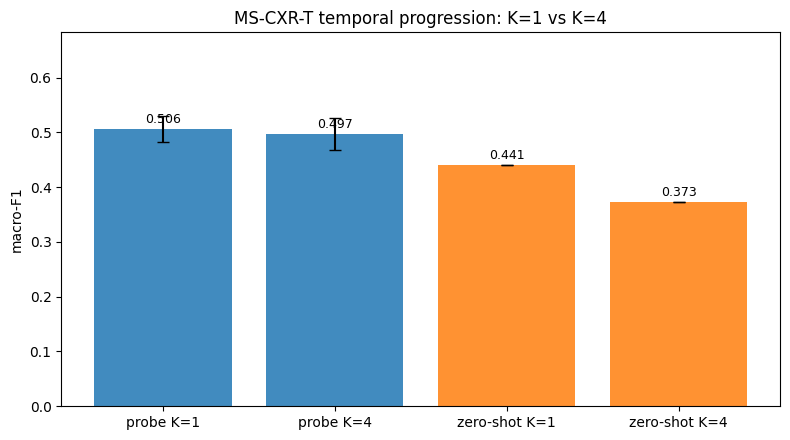

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
names = ['probe K=1', 'probe K=4', 'zero-shot K=1', 'zero-shot K=4']
f1_vals = [probe_k1['f1_mean'], probe_k4['f1_mean'], zs_k1['f1'], zs_k4['f1']]
f1_errs = [probe_k1['f1_std'], probe_k4['f1_std'], 0, 0]
bars = ax.bar(names, f1_vals, yerr=f1_errs, capsize=4,
              color=['#1f77b4','#1f77b4','#ff7f0e','#ff7f0e'], alpha=0.85)
ax.set_ylabel('macro-F1')
ax.set_title('MS-CXR-T temporal progression: K=1 vs K=4')
for b, v in zip(bars, f1_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, max(f1_vals)*1.25 + 0.05)
plt.tight_layout(); plt.show()